# 05 — Control Sample

Stage 5 of 5. For each of the 29 vetted UV-excess QSOs from
[04 — Visual Review & Final Sample](04_visual_review_final_sample.ipynb), finds a nearest-neighbor
comparison QSO -- used as a non-UV-excess control in the follow-up Lick polarimetry program.

**Pipeline:** [01 — Crossmatch](01_crossmatch.ipynb) → [02 — Merge & Dedupe](02_merge_and_dedupe.ipynb)
→ [03 — UV-Excess Selection](03_uv_excess_selection.ipynb) →
[04 — Visual Review & Final Sample](04_visual_review_final_sample.ipynb) → **05 — Control Sample**

**Method:** single nearest neighbor in standardized 3D (z, E(B-V), g-mag) space (each axis divided
by its catalog-wide standard deviation), searched within `FINAL_COMBINED_QSOs_W2M.csv`, excluding
both the 29 known sample members and any other row that independently satisfies the UV-excess
criterion even if never reviewed. Controls may be reused across candidates (true 1-NN, not
forced-unique).

**Inputs:** `data/matched/UV_EXCESS_SAMPLE.csv`, `data/matched/FINAL_COMBINED_QSOs_W2M.csv`

**Output:** `data/matched/uv_excess_with_controls_nn.csv`

**Script reference:** `scripts/matching/build_control_sample_nn.py` -- the one stage 1-5 script
that already loads `config/qso_params.yaml`; this notebook follows the same pattern.

Note: `scripts/matching/build_control_sample_w2m.py` is the superseded binned-E(B-V)+Δz-tolerance
approach; CLAUDE.md says "do not use for analysis" -- intentionally not ported here.

In [1]:
%matplotlib inline

import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
import yaml
import matplotlib.pyplot as plt
import astropy.units as u
from astropy.table import Table
from synphot import units as su

BASE_DIR = Path.cwd().parent
with open(BASE_DIR / "config" / "qso_params.yaml") as f:
    PARAMS = yaml.safe_load(f)

DATA_MATCHED = BASE_DIR / "data" / "matched"
FIGURES_DIR = BASE_DIR / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

SAMPLE_CSV = DATA_MATCHED / "UV_EXCESS_SAMPLE.csv"
FULL_CSV = DATA_MATCHED / "FINAL_COMBINED_QSOs_W2M.csv"
OUT_CSV = DATA_MATCHED / "uv_excess_with_controls_nn.csv"

LAM_FUV = PARAMS["band_wavelengths_AA"]["FUV"] * u.AA
LAM_NUV = PARAMS["band_wavelengths_AA"]["NUV"] * u.AA
LAM_G = PARAMS["band_wavelengths_AA"]["g"] * u.AA
LAM_R = PARAMS["band_wavelengths_AA"]["r"] * u.AA
FLAM_MAX_GALEX_PS1 = PARAMS["flux_outlier_thresholds_flam"]["galex_panstarrs"] * su.FLAM
EBV_MIN = PARAMS["uv_excess"]["ebv_min"]


def mag_arr(col):
    if hasattr(col, 'filled'):
        return np.array(col.filled(np.nan), dtype=float)
    arr = np.array(col, dtype=str)
    arr[arr == '--'] = 'nan'
    return arr.astype(float)


def _flam(tbl, col, lam):
    flam = (mag_arr(tbl[col]) * u.ABmag).to(su.FLAM, u.spectral_density(lam))
    flam[flam > FLAM_MAX_GALEX_PS1] = np.nan
    return flam


def uv_excess_mask(tbl, gmag_col, rmag_col, require_ebv=True, ebv_col='EBV'):
    flam_fuv = _flam(tbl, 'FUVmag', LAM_FUV)
    flam_nuv = _flam(tbl, 'NUVmag', LAM_NUV)
    flam_g = _flam(tbl, gmag_col, LAM_G)
    flam_r = _flam(tbl, rmag_col, LAM_R)

    f_fn = flam_fuv / flam_nuv
    f_ng = flam_nuv / flam_g
    f_gr = flam_g / flam_r

    flux_criterion = ((f_ng > 1) & (f_gr < 1)) | ((f_fn > 1) & (f_ng < 1))

    if require_ebv:
        ebv = mag_arr(tbl[ebv_col])
        return flux_criterion & (ebv > EBV_MIN)
    return flux_criterion


def coalesce(df, primary, fallback):
    """DESI rows carry Z/EBV/gmag, W2M rows carry zsp/ebv/gmag_2 -- take whichever is set."""
    return df[primary].where(df[primary].notna(), df[fallback])

## Nearest-neighbor search

In [2]:
# TARGETID must stay a string: as float64 these 17-digit IDs exceed 2^53 and distinct IDs collapse together.
cand = pd.read_csv(SAMPLE_CSV, dtype={"TARGETID": str})
full = pd.read_csv(FULL_CSV, dtype={"TARGETID": str})

for df in (cand, full):
    df["_z"] = coalesce(df, "Z", "zsp")
    df["_ebv"] = coalesce(df, "EBV", "ebv")
    df["_gmag"] = coalesce(df, "gmag", "gmag_2")

print(f"UV-excess sample: {len(cand)} candidates")

cand_ids = set(cand["TARGETID"].dropna()) | set(cand["designation"].dropna())

full_tbl = Table.from_pandas(full)
desi_mask = uv_excess_mask(full_tbl, gmag_col='gmag', rmag_col='rmag', ebv_col='EBV', require_ebv=True)
w2m_mask = uv_excess_mask(full_tbl, gmag_col='gmag_2', rmag_col='rmag_2', require_ebv=False)
excess_like = np.asarray(desi_mask) | np.asarray(w2m_mask)

id_excluded = full["TARGETID"].isin(cand_ids) | full["designation"].isin(cand_ids)
excluded = id_excluded | excess_like
print(f"Excluded from control pool: {excluded.sum()} "
      f"({id_excluded.sum()} known sample members, {excess_like.sum()} independently UV-excess-like, "
      f"{(id_excluded & excess_like).sum()} overlap)")

pool = full[~excluded].copy()
pool = pool[pool["_z"].notna() & pool["_ebv"].notna() & pool["_gmag"].notna()]
print(f"Control pool size: {len(pool)}")

z_std, ebv_std, gmag_std = pool["_z"].std(), pool["_ebv"].std(), pool["_gmag"].std()
pool_coords = np.column_stack([
    pool["_z"].to_numpy() / z_std,
    pool["_ebv"].to_numpy() / ebv_std,
    pool["_gmag"].to_numpy() / gmag_std,
])

control_idx = []
raw_deltas = []
for _, c in cand.iterrows():
    c_coord = np.array([c["_z"] / z_std, c["_ebv"] / ebv_std, c["_gmag"] / gmag_std])
    dist = np.linalg.norm(pool_coords - c_coord, axis=1)
    best = np.argmin(dist)
    best_row = pool.iloc[best]
    control_idx.append(best_row.name)
    raw_deltas.append((
        abs(c["_z"] - best_row["_z"]), abs(c["_ebv"] - best_row["_ebv"]), abs(c["_gmag"] - best_row["_gmag"]),
    ))

raw_deltas = np.array(raw_deltas)
n_shared = len(control_idx) - len(set(control_idx))
print(f"Control matches found: {len(control_idx)}/{len(cand)} "
      f"({len(set(control_idx))} unique, {n_shared} shared by >1 candidate)")
print(f"Mean |Δz| = {raw_deltas[:, 0].mean():.4f}, Mean |ΔE(B-V)| = {raw_deltas[:, 1].mean():.4f}, "
      f"Mean |Δg| = {raw_deltas[:, 2].mean():.4f}")
print(f"Max  |Δz| = {raw_deltas[:, 0].max():.4f}, Max  |ΔE(B-V)| = {raw_deltas[:, 1].max():.4f}, "
      f"Max  |Δg| = {raw_deltas[:, 2].max():.4f}")

controls = full.loc[sorted(set(control_idx))].copy()
cand["UV_EXCESS"] = "YES"
controls["UV_EXCESS"] = "NO"

out = pd.concat([cand, controls], ignore_index=True)
out = out.drop(columns=["_z", "_ebv", "_gmag"])
out = out.drop_duplicates()
out.to_csv(OUT_CSV, index=False)
print(f"Wrote {len(out)} rows -> {OUT_CSV}")

UV-excess sample: 29 candidates
Excluded from control pool: 34 (29 known sample members, 34 independently UV-excess-like, 29 overlap)
Control pool size: 5447
Control matches found: 29/29 (25 unique, 4 shared by >1 candidate)
Mean |Δz| = 0.0743, Mean |ΔE(B-V)| = 0.0290, Mean |Δg| = 0.2299
Max  |Δz| = 0.3198, Max  |ΔE(B-V)| = 0.1040, Max  |Δg| = 1.5757
Wrote 54 rows -> /Users/alexgs/Documents/UV_Leakage_Geometry/UV_Leakage_Geometry/data/matched/uv_excess_with_controls_nn.csv


## Match quality: candidates vs. controls

New diagnostic (no equivalent plot exists in `build_control_sample_nn.py`, which prints
console-only diagnostics). Each candidate is connected to its matched control by a thin line --
short lines mean a tight NN match in (z, E(B-V)) space.

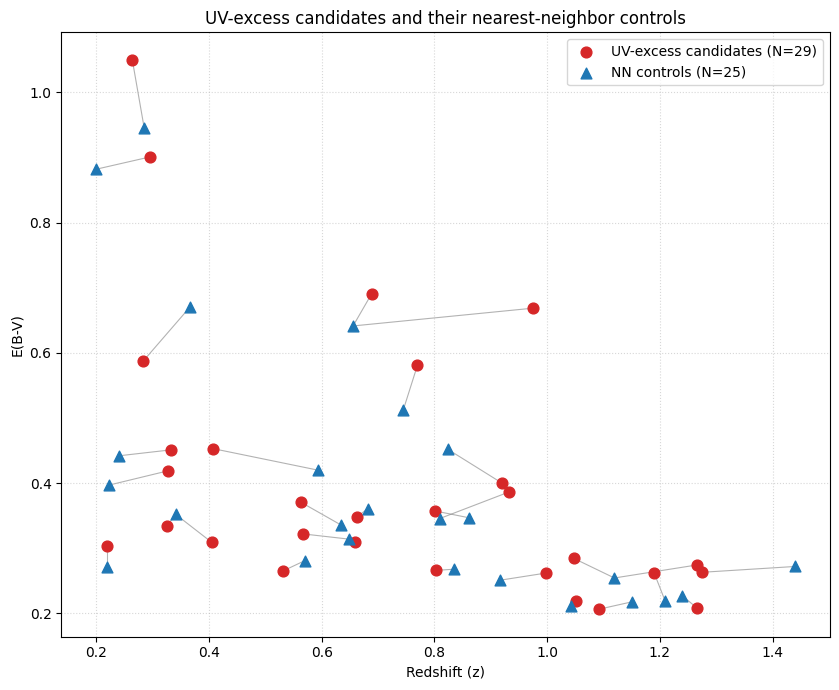

In [3]:
fig, ax = plt.subplots(figsize=(8.5, 7))

for (_, c), ctrl_i in zip(cand.iterrows(), control_idx):
    control_row = full.loc[ctrl_i]
    ax.plot([c["_z"], control_row["_z"]], [c["_ebv"], control_row["_ebv"]],
            color='gray', linewidth=0.8, alpha=0.6, zorder=1)

ax.scatter(cand["_z"], cand["_ebv"], color='tab:red', s=60, zorder=2, label=f'UV-excess candidates (N={len(cand)})')
ax.scatter(controls["_z"], controls["_ebv"], color='tab:blue', s=60, zorder=2, marker='^',
           label=f'NN controls (N={len(controls)})')

ax.set_xlabel('Redshift (z)')
ax.set_ylabel('E(B-V)')
ax.set_title('UV-excess candidates and their nearest-neighbor controls')
ax.grid(linestyle=':', alpha=0.5)
ax.legend(loc='best')
plt.tight_layout()
plt.savefig(FIGURES_DIR / "control_sample_match.png", dpi=150)
plt.show()